In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df = pd.read_csv(r"C:\Users\adin\Downloads\apps.csv")
df.head()

,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [12]:
df.shape

(9659, 14)

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9659 entries, 0 to 9658
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      9659 non-null   int64  
 1   App             9659 non-null   str    
 2   Category        9659 non-null   str    
 3   Rating          8196 non-null   float64
 4   Reviews         9659 non-null   int64  
 5   Size            8432 non-null   float64
 6   Installs        9659 non-null   str    
 7   Type            9659 non-null   str    
 8   Price           9659 non-null   str    
 9   Content Rating  9659 non-null   str    
 10  Genres          9659 non-null   str    
 11  Last Updated    9659 non-null   str    
 12  Current Ver     9651 non-null   str    
 13  Android Ver     9657 non-null   str    
dtypes: float64(2), int64(2), str(10)
memory usage: 1.0 MB


In [14]:
df.describe

<bound method NDFrame.describe of       Unnamed: 0                                                App  \
0              0     Photo Editor & Candy Camera & Grid & ScrapBook   
1              1                                Coloring book moana   
2              2  U Launcher Lite – FREE Live Cool Themes, Hide ...   
3              3                              Sketch - Draw & Paint   
4              4              Pixel Draw - Number Art Coloring Book   
...          ...                                                ...   
9654       10836                                   Sya9a Maroc - FR   
9655       10837                   Fr. Mike Schmitz Audio Teachings   
9656       10838                             Parkinson Exercices FR   
9657       10839                      The SCP Foundation DB fr nn5n   
9658       10840      iHoroscope - 2018 Daily Horoscope & Astrology   

                 Category  Rating  Reviews  Size     Installs  Type Price  \
0          ART_AND_DESIGN     4.1   

In [18]:
# DATA CLEANING

df.drop_duplicates(inplace=True)

# Convert columns
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')

# Clean Installs
df['Installs'] = (
    df['Installs']
    .astype(str)
    .str.replace('+','', regex=False)
    .str.replace(',','', regex=False)
)

df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')

# Clean Price
df['Price'] = (
    df['Price']
    .astype(str)
    .str.replace('$','', regex=False)
)

df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

# Remove null ratings
df.dropna(subset=['Rating'], inplace=True)

print("\nClean Dataset Shape:", df.shape)


Clean Dataset Shape: (8196, 14)


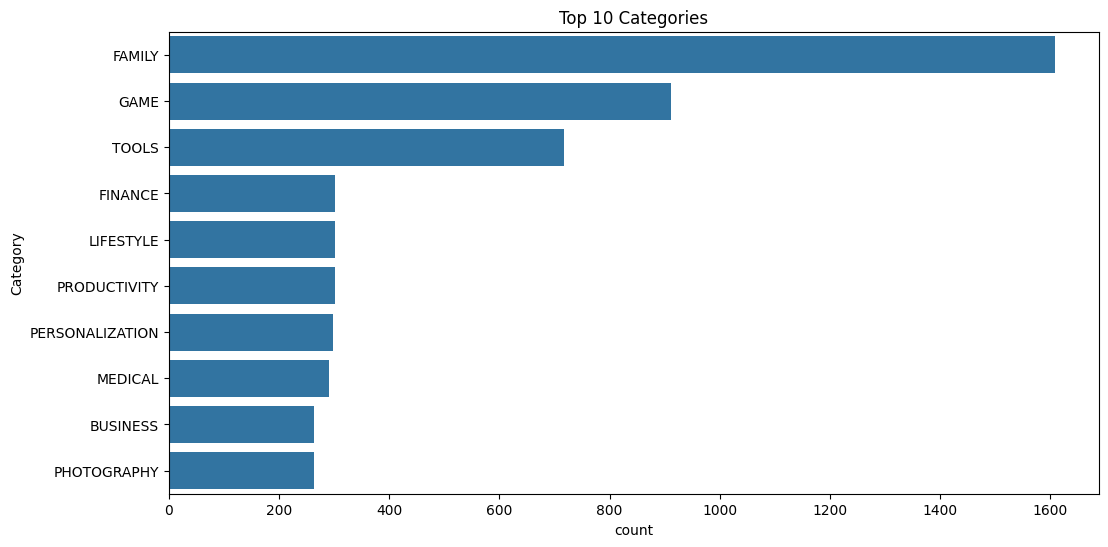

In [19]:
# CATEGORY EXPLORATION

plt.figure(figsize=(12,6))

sns.countplot(
    y='Category',
    data=df,
    order=df['Category'].value_counts().index[:10]
)

plt.title("Top 10 Categories")
plt.show()

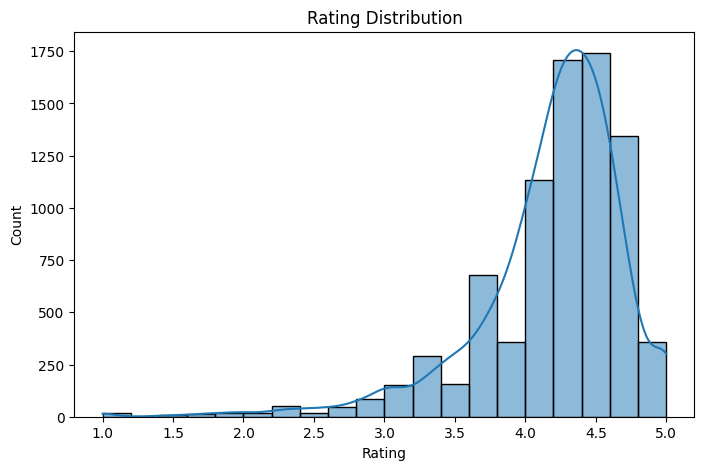

In [20]:
# RATING DISTRIBUTION

plt.figure(figsize=(8,5))

sns.histplot(
    df['Rating'],
    bins=20,
    kde=True
)

plt.title("Rating Distribution")
plt.show()

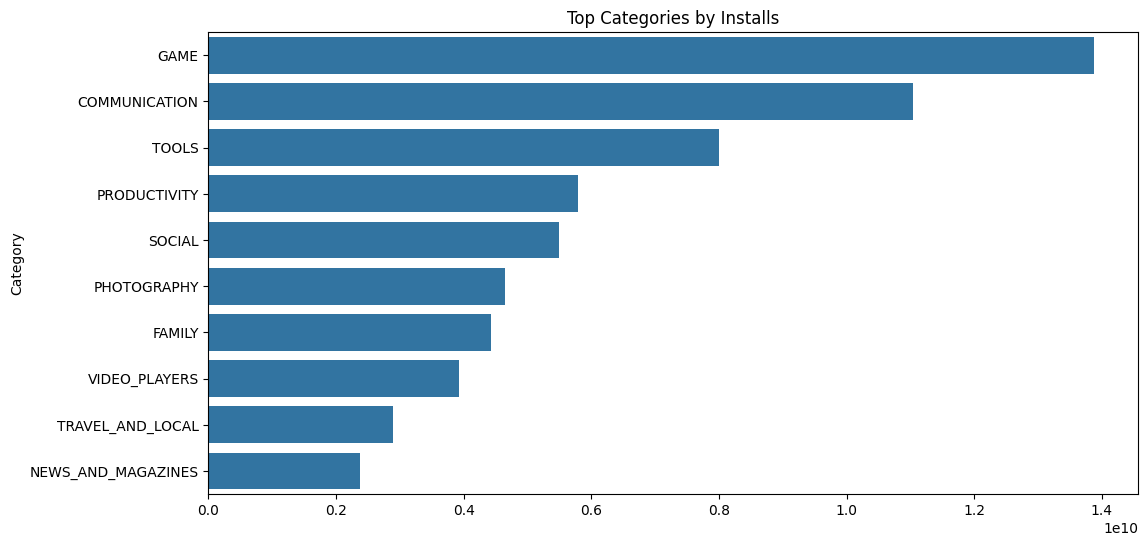

In [21]:
# TOP INSTALLED CATEGORIES

category_installs = (
    df.groupby('Category')['Installs']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=category_installs.values,
    y=category_installs.index
)

plt.title("Top Categories by Installs")
plt.show()

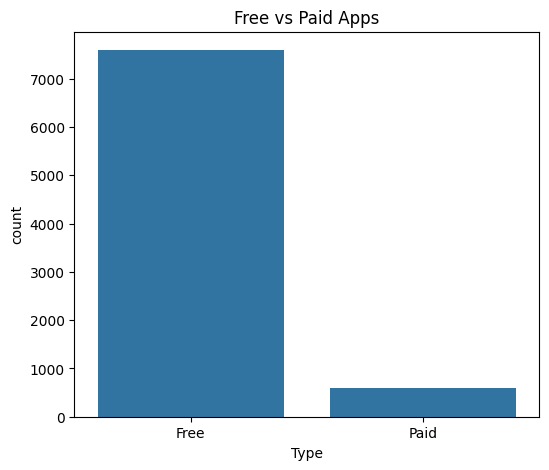

In [22]:
# FREE VS PAID APPS

plt.figure(figsize=(6,5))

sns.countplot(
    x='Type',
    data=df
)

plt.title("Free vs Paid Apps")
plt.show()


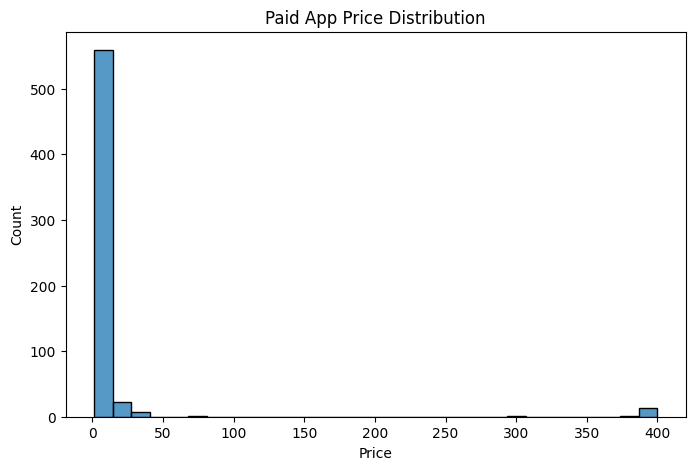

In [23]:
# PRICE DISTRIBUTION

plt.figure(figsize=(8,5))

sns.histplot(
    df[df['Price'] > 0]['Price'],
    bins=30
)

plt.title("Paid App Price Distribution")
plt.show()

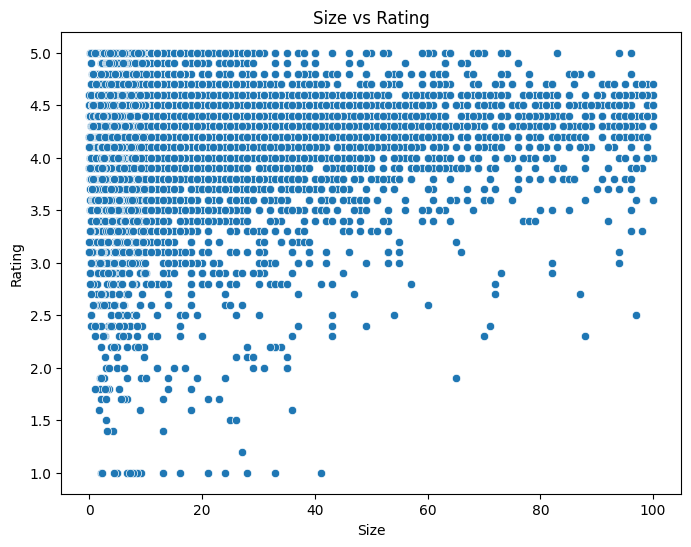

In [24]:
# SIZE VS RATING

plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Size',
    y='Rating',
    data=df
)

plt.title("Size vs Rating")
plt.show()


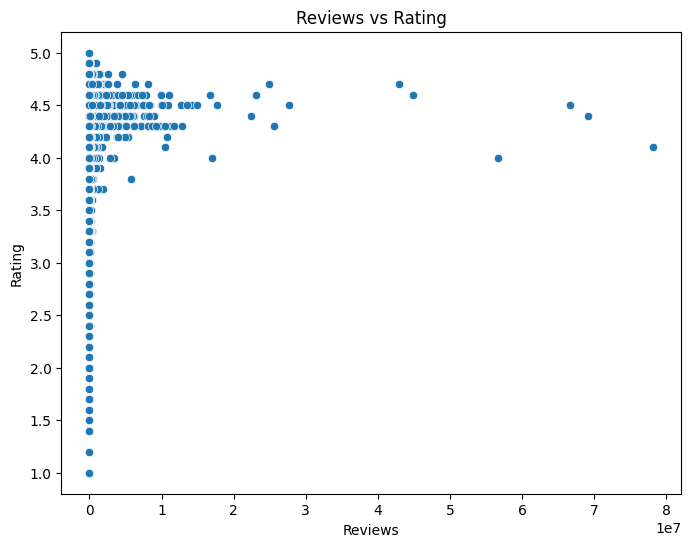

In [25]:
# REVIEWS VS RATING

plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Reviews',
    y='Rating',
    data=df
)

plt.title("Reviews vs Rating")
plt.show()

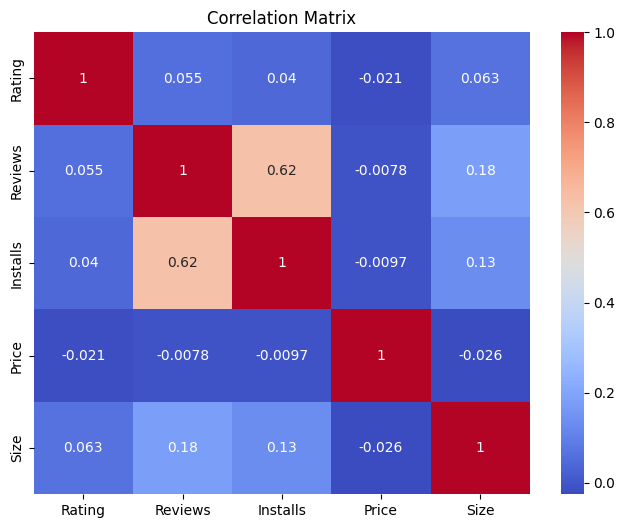

In [26]:
# CORRELATION HEATMAP

plt.figure(figsize=(8,6))

sns.heatmap(
    df[['Rating','Reviews','Installs','Price','Size']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

In [27]:
# TOP RATED APPS

print("\nTop Rated Apps")

print(
    df.sort_values(
        by='Rating',
        ascending=False
    )[['App','Category','Rating']]
    .head(10)
)


Top Rated Apps
                                          App  Category  Rating
9594                         Monster Ride Pro      GAME     5.0
9638                          Fr. Daoud Lamei    FAMILY     5.0
9655         Fr. Mike Schmitz Audio Teachings    FAMILY     5.0
6464  CL Keyboard - Myanmar Keyboard (No Ads)     TOOLS     5.0
6456                                  CL REPL     TOOLS     5.0
6433                               Tic Tac CK    FAMILY     5.0
6429                       CK Employee Portal  BUSINESS     5.0
6428               USMLE Step 2 CK Flashcards    FAMILY     5.0
6417                                   211:CK      GAME     5.0
6746                    CR Tracker for Chests     TOOLS     5.0


In [28]:
# MOST POPULAR APPS

print("\nMost Popular Apps")

print(
    df.sort_values(
        by='Installs',
        ascending=False
    )[['App','Category','Installs']]
    .head(10)
)



Most Popular Apps
                               App             Category    Installs
2191                 Google Photos          PHOTOGRAPHY  1000000000
2002                      Facebook               SOCIAL  1000000000
152              Google Play Books  BOOKS_AND_REFERENCE  1000000000
701              Google Play Games        ENTERTAINMENT  1000000000
2012                       Google+               SOCIAL  1000000000
2003                     Instagram               SOCIAL  1000000000
1356                Subway Surfers                 GAME  1000000000
2977                   Google News   NEWS_AND_MAGAZINES  1000000000
304                          Gmail        COMMUNICATION  1000000000
302   Google Chrome: Fast & Secure        COMMUNICATION  1000000000
